# HSSFLDON - Results Display Notebook

This notebook will be used to display the results of the model.

### Module Imports

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load Results

Load results from our json file. Results are saved in a dict like:

`{ trainingIteration: { passive_or_active: { loss: val, accuracy: val } } }`

In [3]:
resultsPath = "singlemaxconfidence_results.json"
if not os.path.exists(resultsPath):
    print(f"Results file not found at path: {resultsPath}")
else:
    results = json.load(open(resultsPath, "r"))

### Graph Accuracy

We will graph the accuracy for all training iterations for both passive and active learning, using different colors to differentiate the two evaluations for each iteration.

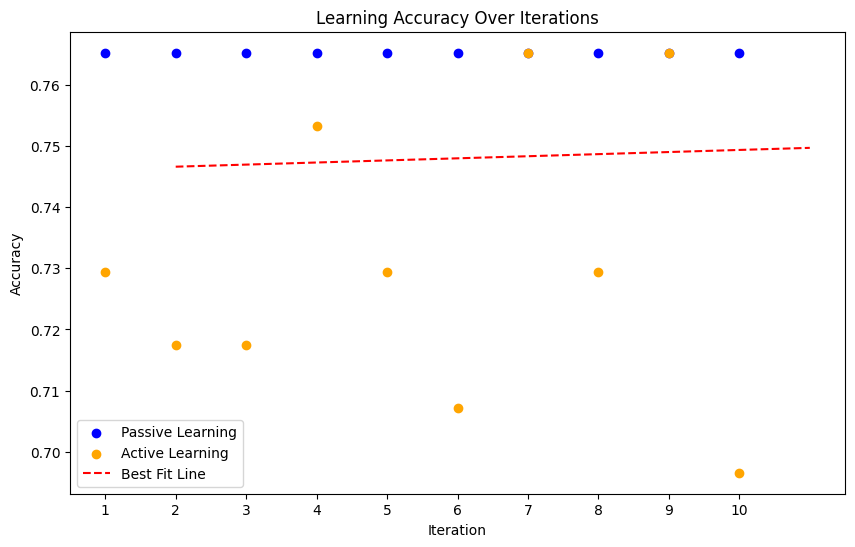

In [4]:
# Extract all accuracies
accuracyDf = pd.DataFrame(columns=["iteration", "learning_mode", "accuracy"])
for iteration in results:
    for learningMode in ["passive", "active"]:
        accuracy = results[iteration][learningMode].get("accuracy", None)
        if accuracy is not None:
            accuracyDf = pd.concat([accuracyDf, pd.DataFrame({"iteration": [iteration], "learning_mode": [learningMode], "accuracy": [accuracy]})], ignore_index=True)

# Make figure for plotting
plt.figure(figsize=(10, 6))

# Plot passive learning accuracies as blue dots
passiveDf = accuracyDf[accuracyDf["learning_mode"] == "passive"]
plt.scatter(passiveDf["iteration"], passiveDf["accuracy"], color="blue", label="Passive Learning")

# Plot active learning accuracies as orange dots
activeDf = accuracyDf[accuracyDf["learning_mode"] == "active"]
plt.scatter(activeDf["iteration"], activeDf["accuracy"], color="orange", label="Active Learning")

# Best fit line
zAccuracy = np.polyfit(accuracyDf["iteration"].astype(float), accuracyDf["accuracy"].astype(float), 1)
pAccuracy = np.poly1d(zAccuracy)
plt.plot(accuracyDf["iteration"].astype(float), pAccuracy(accuracyDf["iteration"].astype(float)), color="red", linestyle="--", label="Best Fit Line")

# Add labels and title
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Learning Accuracy Over Iterations")
plt.legend()
plt.show()

## Graph Loss

Now do the same for loss!

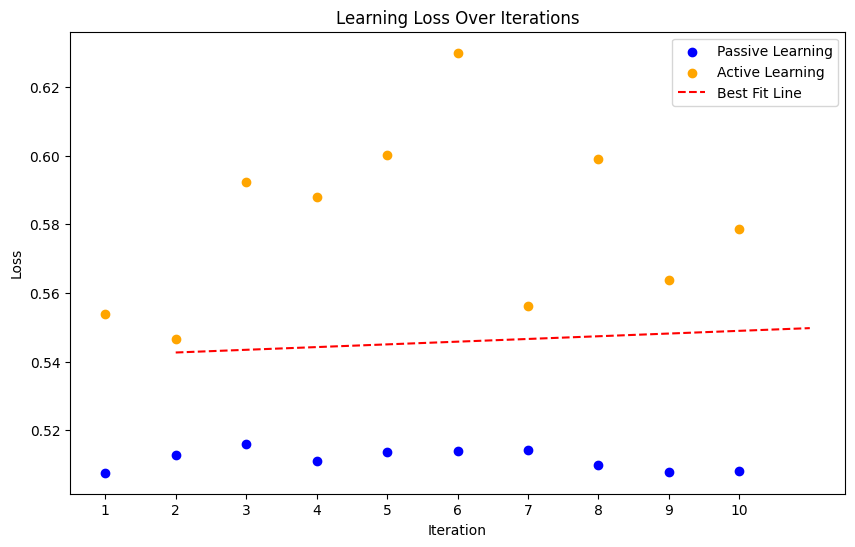

In [5]:
# Extract all losses
lossDf = pd.DataFrame(columns=["iteration", "learning_mode", "loss"])
for iteration in results:
    for learningMode in ["passive", "active"]:
        loss = results[iteration][learningMode].get("loss", None)
        if loss is not None:
            lossDf = pd.concat([lossDf, pd.DataFrame({"iteration": [iteration], "learning_mode": [learningMode], "loss": [loss]})], ignore_index=True)

# Make figure for plotting
plt.figure(figsize=(10, 6))

# Plot passive learning losses as blue dots
passiveDf = lossDf[lossDf["learning_mode"] == "passive"]
plt.scatter(passiveDf["iteration"], passiveDf["loss"], color="blue", label="Passive Learning")

# Plot active learning losses as orange dots
activeDf = lossDf[lossDf["learning_mode"] == "active"]
plt.scatter(activeDf["iteration"], activeDf["loss"], color="orange", label="Active Learning")

# Best fit line
zLoss = np.polyfit(lossDf["iteration"].astype(float), lossDf["loss"].astype(float), 1)
pLoss = np.poly1d(zLoss)
plt.plot(lossDf["iteration"].astype(float), pLoss(lossDf["iteration"].astype(float)), color="red", linestyle="--", label="Best Fit Line")

# Add labels and title
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Learning Loss Over Iterations")
plt.legend()
plt.show()